In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, message="pkg_resources is deprecated")

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import jieba
from stylecloud import gen_stylecloud
from IPython.display import Image

In [6]:
df_tb =pd.read_csv('乐高淘宝数据.csv')
df_tb.head()

,goods_name,shop_name,price,purchase_num,location
0,乐高旗舰店官网悟空小侠系列80012孙悟,乐高官方旗舰店,1299.0,['867人付款'],浙江 嘉兴
1,LEGO乐高 71043收藏版哈利波特霍格沃兹城堡玩具礼物,天猫国际进口超市,3299.0,['259人付款'],浙江 杭州
2,LEGO乐高机械组布加迪42083粉丝收藏旗舰款玩具模型礼物,天猫国际进口超市,2799.0,['441人付款'],浙江 杭州
3,乐高旗舰店官网3月新品76895超级赛车系列法拉利赛车积木玩具男孩,乐高官方旗舰店,199.0,['358人付款'],浙江 嘉兴
4,乐高旗舰店官网3月新品得宝系列10921超级英雄实验室大颗粒益智,乐高官方旗舰店,299.0,['126人付款'],浙江 嘉兴


In [7]:
print("——" * 10)
print('数据集存在重复值个数：')
print(df_tb.duplicated().sum())
print("——" * 10)
print('数据集缺失值情况：')
print(df_tb.isna().sum())
print("——" * 10)
print('数据集各字段类型：')
print(df_tb.dtypes)
print("——" * 10)
print('数据总体概览：')
print(df_tb.info())

————————————————————
数据集存在重复值个数：
993
————————————————————
数据集缺失值情况：
goods_name      0
shop_name       0
price           0
purchase_num    0
location        0
dtype: int64
————————————————————
数据集各字段类型：
goods_name       object
shop_name        object
price           float64
purchase_num     object
location         object
dtype: object
————————————————————
数据总体概览：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4404 entries, 0 to 4403
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   goods_name    4404 non-null   object 
 1   shop_name     4404 non-null   object 
 2   price         4404 non-null   float64
 3   purchase_num  4404 non-null   object 
 4   location      4404 non-null   object 
dtypes: float64(1), object(4)
memory usage: 172.2+ KB
None


In [9]:
# 去除重复值
df_tb.drop_duplicates(inplace=True)
# 删除购买人数为空的记录
df_tb = df_tb[df_tb['purchase_num'].str.contains('人付款')]

# 重置索引
df_tb = df_tb.reset_index(drop=True)
df_tb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3411 entries, 0 to 3410
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   goods_name    3411 non-null   object 
 1   shop_name     3411 non-null   object 
 2   price         3411 non-null   float64
 3   purchase_num  3411 non-null   object 
 4   location      3411 non-null   object 
dtypes: float64(1), object(4)
memory usage: 133.4+ KB


In [11]:
# purchase_num处理
df_tb['purchase_num'] = df_tb['purchase_num'].astype(str)
df_tb['purchase_num'] = df_tb['purchase_num'].str.extract('(\\d+)').astype('int')

# 计算销售额
df_tb['sales_volume'] = df_tb['price'] * df_tb['purchase_num']

#location
df_tb['province'] = df_tb['location'].str.split(' ').str[0]
df_tb.head(5)

,goods_name,shop_name,price,purchase_num,location,sales_volume,province
0,乐高旗舰店官网悟空小侠系列80012孙悟,乐高官方旗舰店,1299.0,867,浙江 嘉兴,1126233.0,浙江
1,LEGO乐高 71043收藏版哈利波特霍格沃兹城堡玩具礼物,天猫国际进口超市,3299.0,259,浙江 杭州,854441.0,浙江
2,LEGO乐高机械组布加迪42083粉丝收藏旗舰款玩具模型礼物,天猫国际进口超市,2799.0,441,浙江 杭州,1234359.0,浙江
3,乐高旗舰店官网3月新品76895超级赛车系列法拉利赛车积木玩具男孩,乐高官方旗舰店,199.0,358,浙江 嘉兴,71242.0,浙江
4,乐高旗舰店官网3月新品得宝系列10921超级英雄实验室大颗粒益智,乐高官方旗舰店,299.0,126,浙江 嘉兴,37674.0,浙江


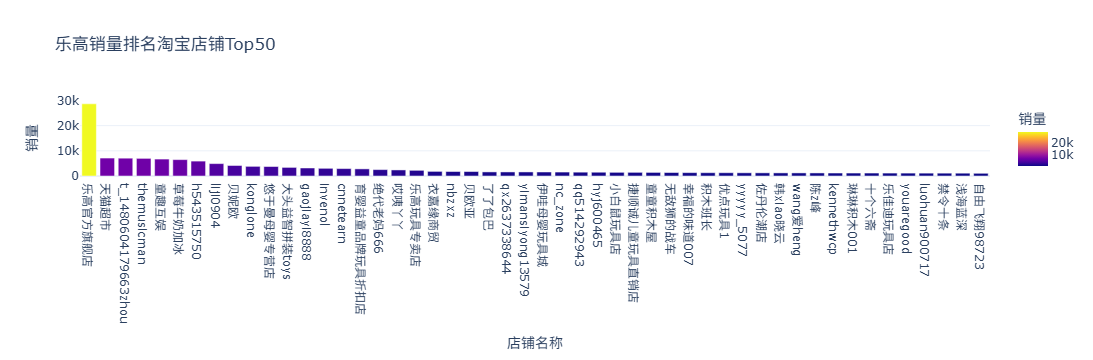

In [13]:
shop_top100 = df_tb.groupby('shop_name')['purchase_num'].sum().sort_values(ascending=False).reset_index()[:50]

px.bar(shop_top100,  # 上面指定的数据
       title="乐高销量排名淘宝店铺Top50",
       template="plotly_white",  # 分别主题设置为：plotly、plotly_dark
       x="shop_name",  # 横坐标
       y="purchase_num",  # 纵坐标
       color="purchase_num",
      labels={"shop_name": "店铺名称", "purchase_num": "销量"})  # 颜色取值


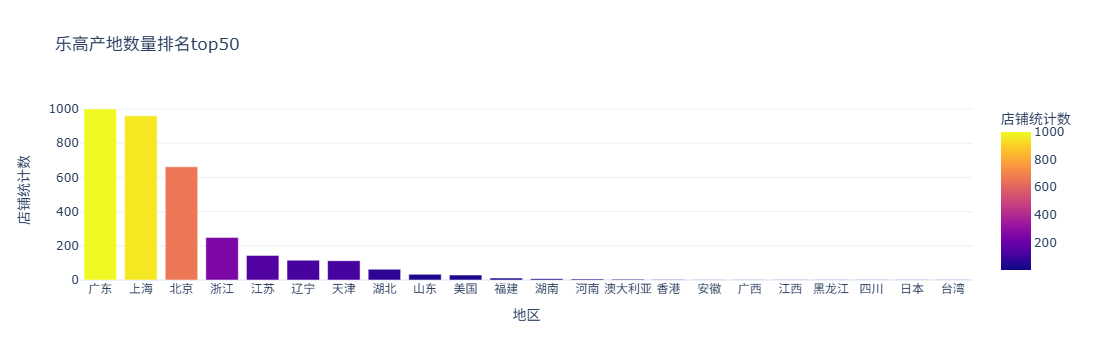

In [14]:
province_top50 = df_tb.province.value_counts().reset_index()[:50]

px.bar(province_top50,  # 上面指定的数据
       title="乐高产地数量排名top50",
       template="plotly_white",  # 分别主题设置为：plotly、plotly_dark
       x="province",  # 修改为正确的列名
       y="count",  # 修改为正确的列名
       color="count",  # 修改为正确的列名
       labels={"province": "地区", "count": "店铺统计数"})  # 更新标签


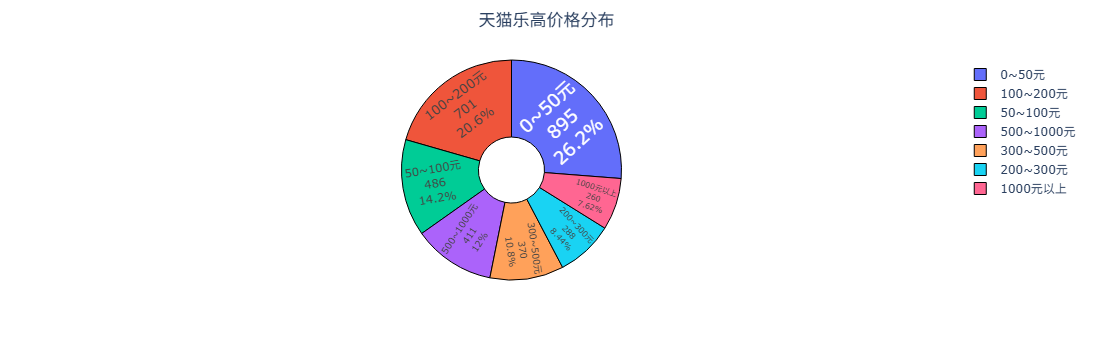

In [15]:
cut_bins = [0,50,100,200,300,500,1000,8888]
cut_labels = ['0~50元', '50~100元', '100~200元', '200~300元', '300~500元', '500~1000元', '1000元以上']

price_cut = pd.cut(df_tb['price'], bins=cut_bins, labels=cut_labels)
price_num = price_cut.value_counts().reset_index()

fig = px.pie(price_num,
             names="price",        # 修改为正确的列名
             values="count",       # 修改为正确的列名
             color="count",        # 修改为正确的列名
             hole=0.3,   # 设置中间空心圆的比例：0-1之间
             labels={"price": "价格区间", "count": "价格数量"}  # 更新标签
            )

fig.update_layout(
    title={   # 设置整个标题的名称和位置
        "text":"天猫乐高价格分布",
        "y":0.96,  # y轴数值
        "x":0.5,  # x轴数值
        "xanchor":"center",  # x、y轴相对位置
        "yanchor":"top"
    }
)
fig.update_traces(
    textposition='inside',
    textinfo='percent+value+label',
    textfont_size=20,
    marker=dict(
                line=dict(color='#000000',
                          width=1)))
fig.show()


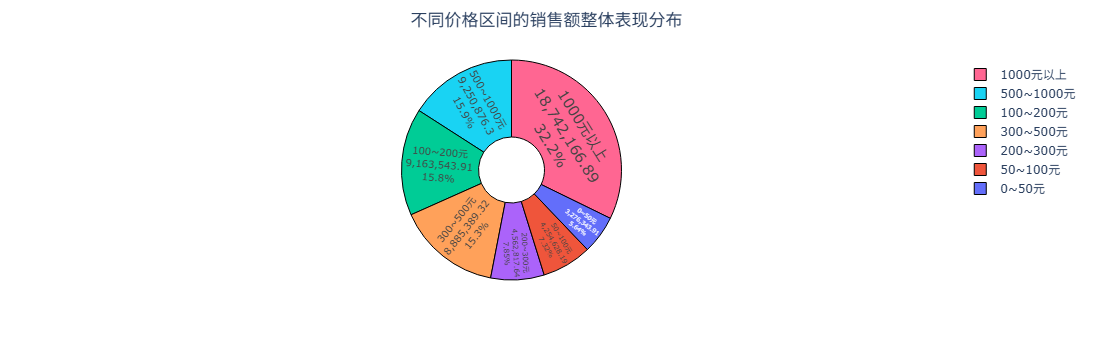

In [17]:
df_tb['price_cut'] = price_cut

cut_purchase = df_tb.groupby('price_cut', observed=False)['sales_volume'].sum().reset_index()

fig = px.pie(cut_purchase,
             names="price_cut",
             values="sales_volume",
             color="sales_volume",
             hole=0.3,   # 设置中间空心圆的比例：0-1之间
             labels={"price_cut": "价格区间", "sales_volume": "销售额"}
            )

fig.update_layout(
    title={   # 设置整个标题的名称和位置
        "text":"不同价格区间的销售额整体表现分布",
        "y":0.96,  # y轴数值
        "x":0.5,  # x轴数值
        "xanchor":"center",  # x、y轴相对位置
        "yanchor":"top"
    }
)
fig.update_traces(
 textposition='inside',
    textinfo='percent+value+label',
    textfont_size=20,
    marker=dict(
                line=dict(color='#000000',
                          width=1)))
fig.show()


In [22]:
def get_cut_words(content_series):
    # 读入停用词表
    stop_words = []

    # 添加关键词
    my_words = ['乐高', '悟空小侠', '大颗粒', '小颗粒']
    for i in my_words:
        jieba.add_word(i, freq=1000)  # 添加词频参数

    # 自定义停用词
    my_stop_words = []
    stop_words.extend(my_stop_words)

    # 分词 - 使用jieba.cut()替代jieba.lcut()
    word_num = list(jieba.cut(content_series.str.cat(sep='。'), cut_all=False))

    # 条件筛选
    word_num_selected = [i for i in word_num if i not in stop_words and len(i)>=2]

    return word_num_selected


In [23]:
text = get_cut_words(content_series=df_tb['goods_name'])
text[:10]


['乐高', '旗舰店', '官网', '悟空小侠', '系列', '80012', '孙悟', 'LEGO', '乐高', '71043']

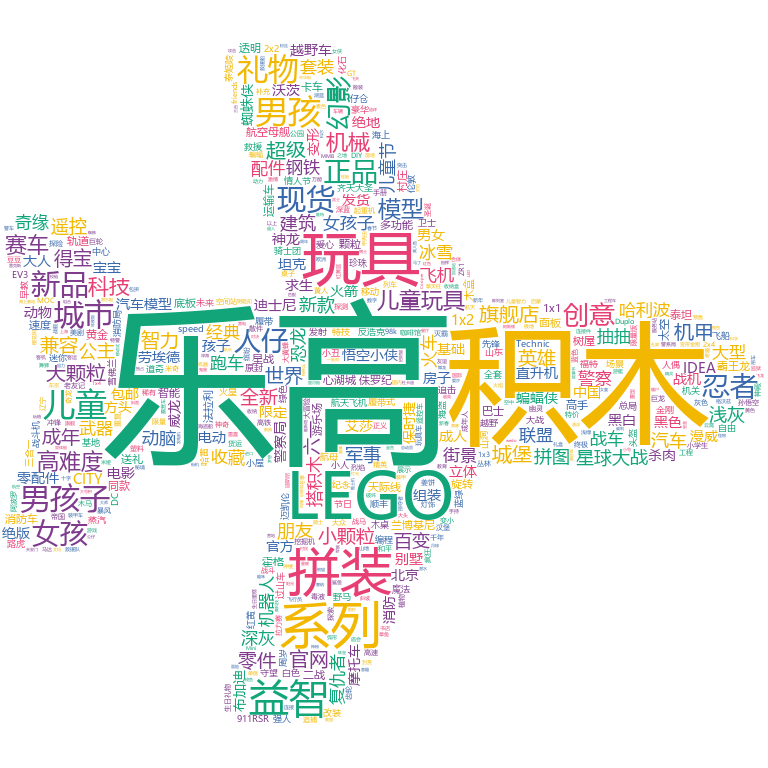

In [24]:
# 绘制词云图

from PIL import ImageDraw, ImageFont

if not hasattr(ImageDraw.ImageDraw, 'textsize'):
    def _text_size(self, text, font=None, *_, **__):
        left, top, right, bottom = (font or self.getfont()).getbbox(text)
        return right - left, bottom - top
    ImageDraw.ImageDraw.textsize = _text_size

gen_stylecloud(
    text=' '.join(text),
    collocations=False,
    font_path=r'C:\Windows\Fonts\msyh.ttc',
    icon_name='fas fa-plane',
    size=768,
    output_name='淘宝乐高标题词云图.png'
)
Image(filename='淘宝乐高标题词云图.png')



### 3. 乐高天猫旗舰店数据分析及其可视化

#### 3.1 乐高天猫旗舰店数据概览

In [25]:
df_tm = pd.read_csv('天猫乐高旗舰店数据.csv')
df_tm.head()


,title,age_range,price,sales_num,comment_num,color_cat
0,乐高哈利波特系列霍格沃茨城堡71043成人收藏,适用年龄范围：16+岁,3999.00,139,511,71043 霍格沃兹城堡
1,乐高旗舰店Ideas系列21319中央咖啡厅老友记收藏送礼,适用年龄16岁+,699.00,454,1299,无
2,乐高旗舰店官网2020年新品10269 哈雷戴维森®肥仔®摩托车成人收藏,NaN,999.00,276,509,无
3,乐高旗舰店官网2020年新品Ideas系列21320恐龙化石男女孩玩具礼物,NaN,599.00,359,524,无
4,乐高旗舰店官网10874智能蒸汽火车遥控轨道大颗粒益智积木玩具,适用年龄范围：2-5岁,549.00,806,2884,10874蒸汽智能火车


In [26]:
df_tm.drop_duplicates(inplace=True)

# 价格处理
def transform_price(x):
    if '-' in x:
        return (float(x.split('-')[1]) - float(x.split('-')[0]))/2
    else:
        return x

# 价格转换
df_tm['price'] = df_tm.price.apply(lambda x:transform_price(x)).astype('float')

# 使用平均值填充缺失值
df_tm['sales_num'] = df_tm.sales_num.replace('无',200)

#转换类型
df_tm['sales_num'] = df_tm.sales_num.astype('int')


df_tm['title'] = df_tm.title.str.replace('乐高旗舰店|官网|2020年', '')

#销售额
df_tm['sales_volume'] = df_tm['sales_num'] * df_tm['price']


rank_top50 = df_tm.groupby('title')['sales_num'].sum().sort_values(ascending=False).reset_index()[:50]


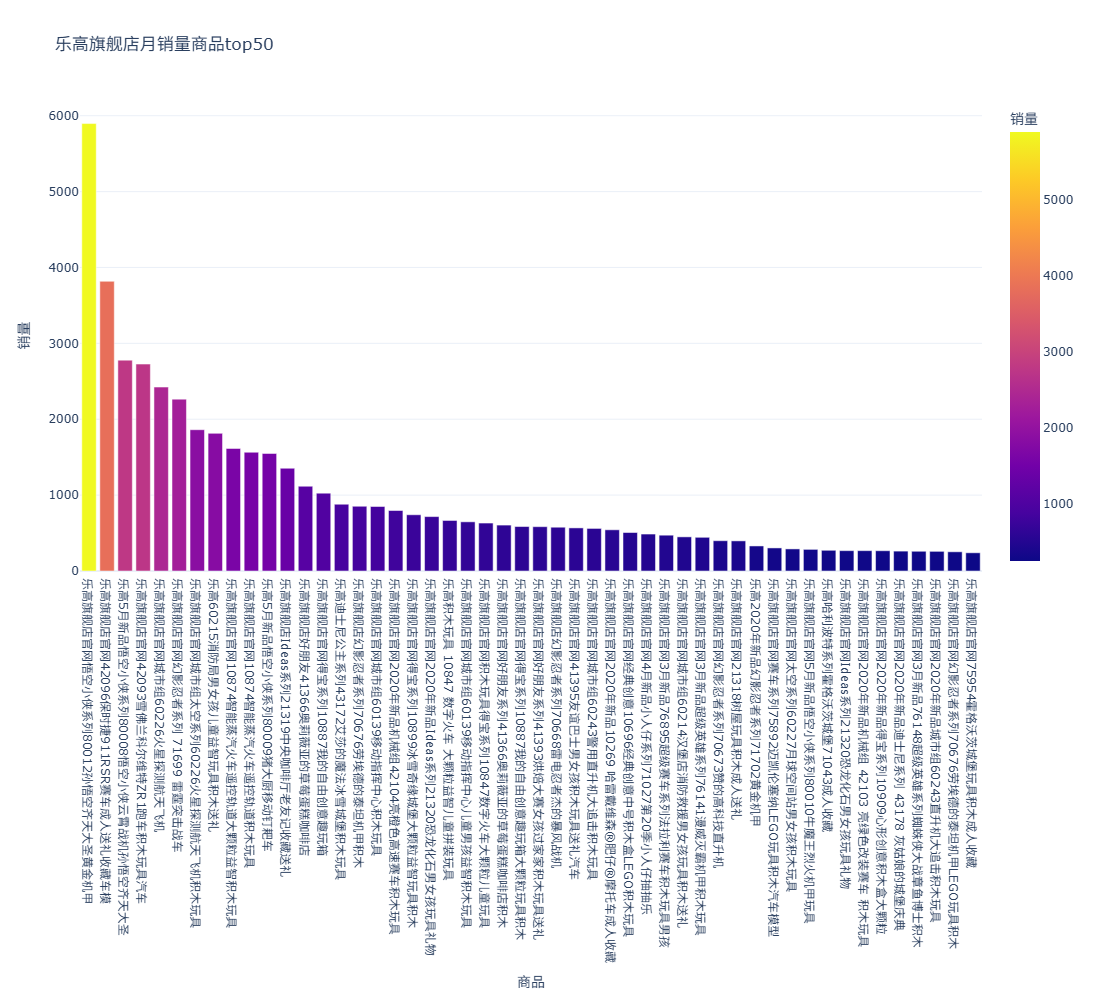

In [27]:
px.bar(rank_top50,  # 上面指定的数据
       title="乐高旗舰店月销量商品top50",
       template="plotly_white",  # 分别主题设置为：plotly、plotly_dark
       x="title",  # 横坐标
       y="sales_num",  # 纵坐标
       color="sales_num",
        height=1000,  # 自定义高度为600
      labels={"title": "商品", "sales_num": "销量"})  # 颜色取值


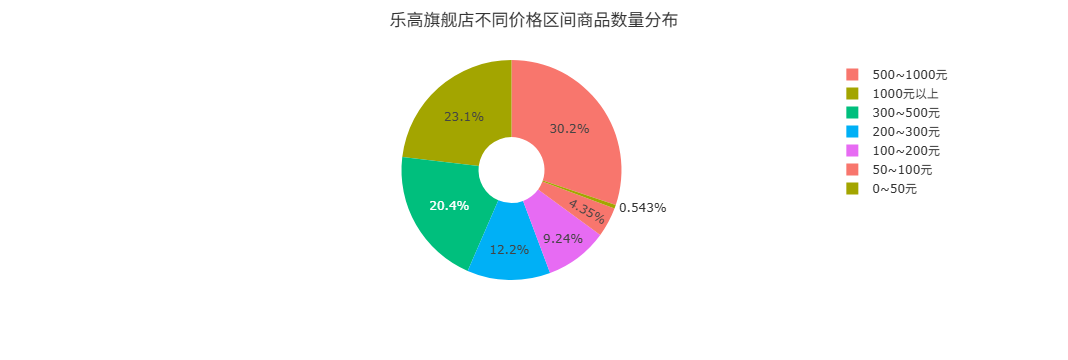

In [28]:
cut_bins = [0,50,100,200,300,500,1000,8888]
cut_labels = ['0~50元', '50~100元', '100~200元', '200~300元', '300~500元', '500~1000元', '1000元以上']

price_cut = pd.cut(df_tm['price'], bins=cut_bins, labels=cut_labels)
price_num = price_cut.value_counts().reset_index()

# 创建图表
fig = px.pie(
    price_num,
    names="price",        # 修改为正确的列名
    values="count",       # 修改为正确的列名
    color="count",        # 修改为正确的列名
    hole=0.3,
    labels={"price": "价格区间", "count": "价格数量"},  # 更新标签
    template="ggplot2"
)

# 修改布局
fig.update_layout(
    title={
        "text": "乐高旗舰店不同价格区间商品数量分布",
        "y": 0.96,
        "x": 0.5,
        "xanchor": "center",
        "yanchor": "top"
    }
)

fig.show()


3.5 乐高旗舰店不同价格区间的销售额整体表现m

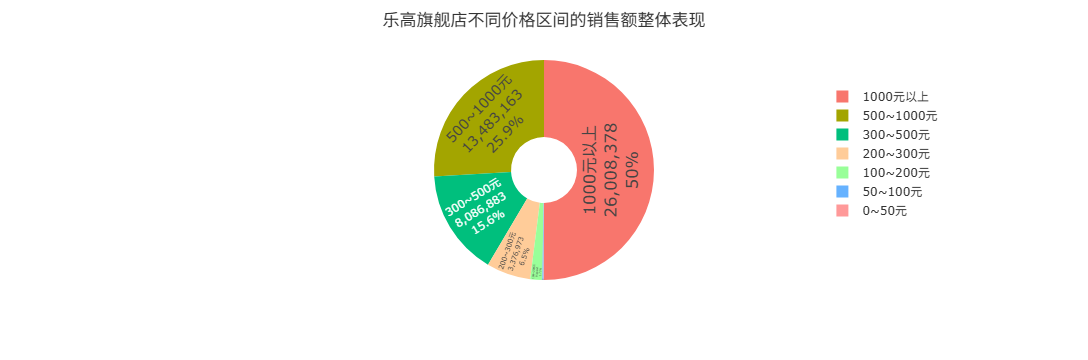

In [29]:
# 添加列
df_tm['price_cut'] = price_cut
# 修改这行，显式添加 observed=False 参数
cut_purchase = df_tm.groupby('price_cut', observed=False)['sales_volume'].sum().reset_index()

# 创建图表
fig = px.pie(
    cut_purchase,
    names="price_cut",
    values="sales_volume",
    color="sales_volume",
    hole=0.3,
    labels={"price_cut": "价格区间", "sales_volume": "销售额"},
    template="ggplot2"  # 使用ggplot2样式模板
)

# 修改布局
fig.update_layout(
    title={
        "text": "乐高旗舰店不同价格区间的销售额整体表现",
        "y": 0.96,
        "x": 0.5,
        "xanchor": "center",
        "yanchor": "top"
    },
    legend=dict(
        yanchor="top",
        y=0.9,
        xanchor="left",
        x=0.8,
        orientation="v"
    )
)

# 自定义颜色方案
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
fig.update_traces(textposition='inside',
    textinfo='percent+value+label',
    textfont_size=20,marker=dict(colors=colors))

# 显示图表
fig.show()


3.6 乐高旗舰店商品标题词云图

In [36]:
text = get_cut_words(content_series=df_tm['title'])
text[:6]


['乐高', '哈利波', '系列', '霍格', '沃茨', '城堡']

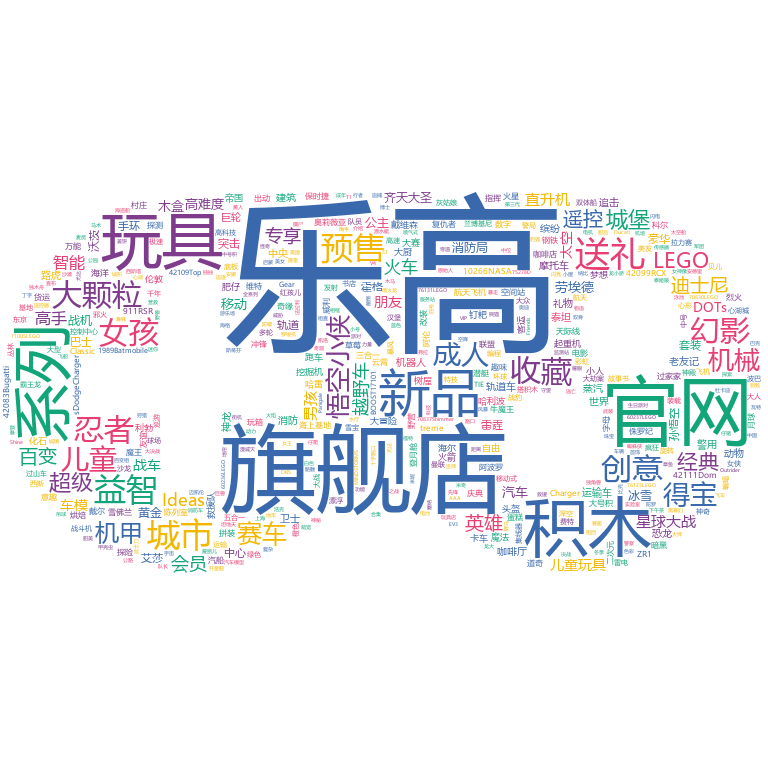

In [37]:
gen_stylecloud(
    text=' '.join(text),
    collocations=False,
    font_path=r'‪C:\Windows\Fonts\msyh.ttc',
    icon_name='fas fa-gamepad',
    size=768,
    output_name='乐高旗舰店商品标题词云图.png'
)
Image(filename='乐高旗舰店商品标题词云图.png')